In [23]:
import pandas as pd
import numpy as np
import copy as cp
import matplotlib.pyplot as plt

In [24]:
train = pd.read_csv(r"C:\Users\SHREYAS ROY\Desktop\CarPrices\CarPrice_Assignment.csv")
#test = pd.read_csv(r"")

train = train.dropna() #can be changed later to fillna() with mean, median, forward/backward fill, *forward/backward mean fill
#test = test.dropna()
train['carCompany'] = train['CarName'].apply(lambda x: x.split()[0])
train = pd.get_dummies(train, columns = ['symboling','carCompany','fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation','enginetype','cylindernumber','fuelsystem'], drop_first = True) #auto performs one hot encoding and creates new categories acc; 
#drop_first -> k-1 hot encoding
#test = pd.get_dummies(test, columns = ['symboling','CarName','fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation','cylindernumber','fuelsystem'], drop_first = True)
#test = test.reindex(columns=train.columns, fill_value=0) 

In [25]:
targetCol = 'price'
rawFeatures = train.drop(columns = [targetCol, 'car_ID', 'CarName']).to_numpy()
target = train[targetCol].to_numpy() 
#rawTestFeatures = test.drop(columns = [targetCol, 'car_ID']).to_numpy()
#testCases = test[targetCol].to_numpy()

In [26]:
rawFeatures = rawFeatures.astype(np.float64) #Originally dtype was 'object' instead of float
#rawTestFeatures = rawTestFeatures.astype(np.float64)

# Z-Score Normalization
# NOTE:  One hot encoded features may be exempt from normalization
mean = np.mean(rawFeatures, axis=0) 
std = np.std(rawFeatures, axis=0)

features = (rawFeatures - mean) / std # Assume std can never be 0
#testFeatures = (rawTestFeatures - mean) / std # NOTE: Used same mean and std for testFeature Normalization

In [27]:
def costFunction(x, y, w, b) -> float:
    m = x.shape[0]
    yPred = np.dot(x,w) + b 
    error = yPred - y
    totalCost = np.dot(error, error) / (2*m)
    return totalCost

def computeGradient(x, y, w, b) -> tuple:
    m = x.shape[0]
    dw, db = 0, 0
    yPred = np.dot(x, w) + b
    error = yPred - y
    dw = np.dot(x.T, error) / m 
    db = np.sum(error) / m
    return dw, db

def gradientDescent(features, target, wIn, b, alpha, lm, iterations) -> tuple:
    m = features.shape[0]
    #For Graphing purposes:
    J_history = []
    w = cp.deepcopy(wIn)
    for i in range(0, iterations + 1):
        dw, db = computeGradient(features, target, w, b)
        w = w * (1 - (alpha * lm)/ m) - alpha * dw
        b = b - alpha * db
        if i % (iterations // 10) == 0:
            cost = costFunction(features, target, w, b)
            J_history.append(cost)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]): .4f}   ")
    return w, b, J_history

In [28]:
wIn = np.zeros(features.shape[1])
w, b , J_history = gradientDescent(features, target, wIn, 0, 0.1, 0.1, 100_000)

Iteration    0: Cost  77388934.6143   
Iteration 10000: Cost  1039587.9283   
Iteration 20000: Cost  1039257.9389   
Iteration 30000: Cost  1039237.4130   
Iteration 40000: Cost  1039235.9353   
Iteration 50000: Cost  1039235.8277   
Iteration 60000: Cost  1039235.8198   
Iteration 70000: Cost  1039235.8193   
Iteration 80000: Cost  1039235.8192   
Iteration 90000: Cost  1039235.8192   
Iteration 100000: Cost  1039235.8192   


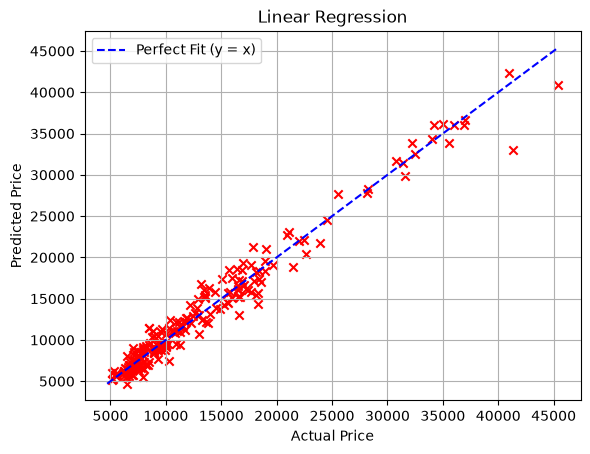

In [29]:
yPred = np.dot(features, w) + b
plt.scatter(target, yPred, marker='x', c='r') 
# Reference diagonal line (Perfect model line where y_actual == y_pred)
min_val = min(target.min(), yPred.min())
max_val = max(target.max(), yPred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'b--', label='Perfect Fit (y = x)')
# Set the title
plt.title("Linear Regression")
plt.ylabel('Predicted Price')
plt.xlabel('Actual Price')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
mse = np.mean((yPred - target) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(yPred - target))

ss_res = np.sum((target - yPred) ** 2)
ss_tot = np.sum((target - np.mean(target)) ** 2)
r2_score = 1 - (ss_res / ss_tot) 

nonZeroTestCases = target != 0 
wmape = np.sum(np.abs(target[nonZeroTestCases] - yPred[nonZeroTestCases]) / np.sum(target[nonZeroTestCases])) * 100
accuracy_pct = 100 - wmape

print("TEST SET EVALUATION: ")
print(f"Test Cost J(w,b)     : {mse / 2.0:.4f}")
print(f"Root Mean Sq Error   : ${rmse:.2f} (Average deviation)")
print(f"Mean Absolute Error  : ${mae:.2f}")
print(f"R² Score             : {r2_score:.4f} ({r2_score * 100:.2f}% fit)")
print(f"Model Accuracy       : {accuracy_pct:.2f}%")

TEST SET EVALUATION: 
Test Cost J(w,b)     : 1039235.8192
Root Mean Sq Error   : $1441.69 (Average deviation)
Mean Absolute Error  : $1031.96
R² Score             : 0.9673 (96.73% fit)
Model Accuracy       : 92.23%


predictedVal = np.dot(testFeatures, w) + b
#predictedVal = np.clip(np.dot(testFeatures, w) + b, a_min=0, a_max=None) # It is noticed that sometimes our predicted values are less than 0 

mse = np.mean((predictedVal - testCases) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predictedVal - testCases))

ss_res = np.sum((testCases - predictedVal) ** 2)
ss_tot = np.sum((testCases - np.mean(testCases)) ** 2)
r2_score = 1 - (ss_res / ss_tot) 

nonZeroTestCases = testCases != 0 
wmape = np.sum(np.abs(testCases[nonZeroTestCases] - predictedVal[nonZeroTestCases]) / np.sum(testCases[nonZeroTestCases])) * 100
accuracy_pct = 100 - wmape

print("TEST SET EVALUATION: ")
print(f"Test Cost J(w,b)     : {mse / 2.0:.4f}")
print(f"Root Mean Sq Error   : ${rmse:.2f} (Average deviation)")
print(f"Mean Absolute Error  : ${mae:.2f}")
print(f"R² Score             : {r2_score:.4f} ({r2_score * 100:.2f}% fit)")
print(f"Model Accuracy       : {accuracy_pct:.2f}%")

plt.figure(figsize=(8, 6))
plt.scatter(testCases, predictedVal, marker='o', c='red', label='Test Predictions')

min_val = min(testCases.min(), predictedVal.min())
max_val = max(testCases.max(), predictedVal.max())
plt.plot([min_val, max_val], [min_val, max_val], 'b--', linewidth=2, label='Perfect Fit (y = x)')

plt.title("Test Set: Actual vs. Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.grid(True)
plt.show()